In [430]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import ephem
import math
from datetime import timedelta
import cartopy.crs as ccrs
import cartopy
import matplotlib.path as mpath
from matplotlib.patches import ConnectionPatch


In [431]:
erads = xr.open_dataset("/global/homes/r/rudisill/era_interim/download.nc")

FileNotFoundError: [Errno 2] No such file or directory: b'/global/homes/r/rudisill/era_interim/download.nc'

In [ ]:
params = xr.open_dataset("era_interim/era5_1979_2022_north_america_regime_z500_params.nc",  decode_times=False)

In [ ]:
params.z_climo

<xarray.DataArray 'z_climo' (doy: 365, latitude: 41, longitude: 101)>
[1511465 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float32 80.0 78.5 77.0 75.5 ... 24.5 23.0 21.5 20.0
  * longitude  (longitude) float32 -180.0 -178.5 -177.0 ... -33.0 -31.5 -30.0
Dimensions without coordinates: doy
Attributes:
    units:      gpm
    long_name:  Daily 1979-2022 ERA5 climate

In [ ]:
era_coarsen = erads.isel(expver=0).coarsen(latitude=6, longitude=6, side='left', boundary='pad').mean()

In [ ]:
era_coarsen_interp = era_coarsen.interp(latitude = params.latitude, longitude = params.longitude)

In [ ]:
kolias = xr.open_dataset("/global/homes/r/rudisill/gshare/sail_data_will/data_store_sail_period/kollias/cbh_kolias2.nc").to_pandas()
cloud_present_kolias = kolias.copy()
cloud_present_kolias[cloud_present_kolias == -1] = 0
cloud_present_kolias[cloud_present_kolias > 0] = 1


kolias_lt_4000 = kolias.where(kolias < 4000)
kolias_lt_4000.fillna(-1, inplace=True)
cloud_present_kolias_lt_4000 = kolias_lt_4000.copy()
cloud_present_kolias_lt_4000[cloud_present_kolias_lt_4000 == -1] = 0
cloud_present_kolias_lt_4000[cloud_present_kolias_lt_4000 > 0] = 1


In [ ]:
df=pd.read_csv("/global/homes/r/rudisill/gshare/sail_data_will/rrtmg/rrtmgClearSkySW_and_M1Obs_SailPeriod_all_o3.csv",index_col=0, parse_dates=True)


In [ ]:
qcrad = pd.read_csv("/global/homes/r/rudisill/gshare/sail_data_will/data_store_sail_period/qcrad/sail_BestEstimate_down_short_hemisp.csv", index_col=0, parse_dates=True)
qcrdf=pd.DataFrame({"swd":qcrad['0']})


In [ ]:
df['qcrad'] = qcrdf['swd'].resample("1h").mean()

In [ ]:
daily_cre = (df.swd -   df.qcrad).resample("1d").mean()

In [ ]:
warm_season = daily_cre[daily_cre.index.month.isin([4,5,6,7,8,9])]
cool_season = daily_cre[daily_cre.index.month.isin([10,11,12,1,2,3])]

In [ ]:
pctl = .5 # 90th percentile
warm_season_cloud_pattern = era_coarsen_interp.sel(time=warm_season[warm_season > warm_season.quantile(pctl)].index).mean(dim="time")
warm_season_cloud_pattern_normal = params.z_climo.loc[params.z_climo.doy.isin(warm_season.index.dayofyear)].mean(dim="doy")
hgt_anom_warm = warm_season_cloud_pattern.z / 9.81 - warm_season_cloud_pattern_normal

In [ ]:
cool_season_cloud_pattern = era_coarsen_interp.sel(time=cool_season[cool_season > cool_season.quantile(pctl)].index).mean(dim="time")
cool_season_cloud_pattern_normal = params.z_climo.loc[params.z_climo.doy.isin(cool_season.index.dayofyear)].mean(dim="doy")
hgt_anom_cool = cool_season_cloud_pattern.z/ 9.81  - cool_season_cloud_pattern_normal

In [ ]:
#hgt_anom_cool = ((cool_season_cloud_pattern.z*.1) - cool_season_cloud_pattern_normal)

In [ ]:
#ax = plt.subplot(111, projection=ccrs.NorthPolarStereo(central_longitude=-100))
def make_figure(ax, anom, wind, vmin=-200, vmax=200):
    ax.gridlines()
    ax.coastlines()
    ax.gridlines(alpha=.2)
    ### plot the data 

    cb = ax.pcolormesh(anom.longitude, 
                       anom.latitude, 
                       anom, 
                       cmap='RdBu_r', 
                       transform=ccrs.PlateCarree(), 
                       shading='auto', vmax=vmax, vmin=vmin)

    wind_downsample = wind[{'latitude': slice(None, None, 3), 
                            'longitude': slice(None, None, 3)}]

    # qplot = wind_downsample.plot.quiver('longitude', 
    #                                     'latitude', 
    #                                     'u', 
    #                                     'v',
    #                                     transform=ccrs.PlateCarree(), 
    #                                     scale=250, 
    #                                     ax=ax, 
    #                                     add_guide=False)

    #fig.colorbar(cb, ax=ax, orientation='horizontal')
    ###
    xlim = [-165, -65]
    ylim = [25, 70]

#    xlim = [-140, -80]
#    ylim = [30, 60]

    rect = mpath.Path([[xlim[0], ylim[0]],
                    [xlim[1], ylim[0]],
                    [xlim[1], ylim[1]],
                    [xlim[0], ylim[1]],
                    [xlim[0], ylim[0]],
                    ]).interpolated(20)

    proj_to_data = ccrs.PlateCarree()._as_mpl_transform(ax) - ax.transData
    rect_in_target = proj_to_data.transform_path(rect)
    ax.set_boundary(rect_in_target)

    erw_latitude  = 38.956381  # ERW
    erw_longitude = -106.984322  # ERW

    ax.scatter(erw_longitude, erw_latitude, transform=ccrs.PlateCarree(), s=15, facecolor='black', edgecolor='pink', linewidth=2)
    ax.set_extent([xlim[0], xlim[1], ylim[0], ylim[1]], crs=ccrs.PlateCarree())
    #    ax.set_title(f"500mb Geopotential Height Anomaly (ERA5 1979-2022) \n {the_time}")

    return cb


In [ ]:
# fig=plt.figure(figsize=(6,2*2))                                    

# the_time = pd.to_datetime('2023-02-03')

# nrows=1
# ncols=2
# fig, axs = plt.subplots(nrows=nrows,
#                         ncols=ncols,
#                         subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-100)},
#                         figsize=(8,3.5))

# cb1 = make_figure(axs[0], hgt_anom_cool, cool_season_cloud_pattern)
# cb1 = make_figure(axs[1], hgt_anom_warm, warm_season_cloud_pattern)

# axs[0].set_title("Cool Season")
# axs[1].set_title("Warm Season")

# cax = fig.add_axes([.35, .1, 0.3, 0.035])
# cbar = fig.colorbar(cb, cax=cax, orientation='horizontal')
# cbar.set_label("Geopotential Height Anomaly (m)")


In [ ]:
cloud_present_kolias_lt_4000_localtime = cloud_present_kolias_lt_4000.shift(-7, freq='1h')
warmcloud = cloud_present_kolias_lt_4000_localtime[cloud_present_kolias_lt_4000_localtime.index.month.isin([4,5,6,7,8,9])]
coldcloud = cloud_present_kolias_lt_4000_localtime[cloud_present_kolias_lt_4000_localtime.index.month.isin([10,11,12,1,2,3])]

In [ ]:
# k=0
# bootstraplist_sq = []
# for g in coldcloud.groupby(coldcloud.index.hour):
#     j=0
#     bootstraplist = []
#     for n in range(100):
#         bootstraplist.append(g[1].sample(250).mean().values)
#         j+=1        
#     bootstraplist_sq.append(bootstraplist)
# #    ax.boxplot(np.array(bootstraplist), positions=[k], widths=0.5, patch_artist=True, showfliers=False)
#     k+=1

# # now do the warm season

# k=0
# bootstraplist_sq2 = []
# for g in warmcloud.groupby(warmcloud.index.hour):
#     j=0
#     bootstraplist = []
#     for n in range(100):
#         bootstraplist.append(g[1].sample(250).mean().values)
#         j+=1        
# #    ax.boxplot(np.array(bootstraplist), positions=[k], widths=0.5, patch_artist=True, showfliers=False, boxprops=dict(facecolor="red"))
#     bootstraplist_sq2.append(bootstraplist)
#     k+=1


In [ ]:
# fig, ax = plt.subplots(figsize=(5,3.5))
# for i,bs in enumerate(bootstraplist_sq):
#     bp1=ax.boxplot(np.array(bs), positions=[i], widths=0.5, patch_artist=True, showfliers=False, boxprops=dict(facecolor="blue"))

# for i,bs in enumerate(bootstraplist_sq2):
#     bp2=ax.boxplot(np.array(bs), positions=[i], widths=0.5, patch_artist=True, showfliers=False, boxprops=dict(facecolor="red"))

# ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ['Cold Season', 'Warm Season'], loc='upper left')
# ax.set_xlabel("Hour of Day (Local Time)")
# ax.set_ylabel("P(Cloud)")
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

### Compute cloud anomalies

### warm seaason

In [ ]:
nocloud_warm   = warmcloud.resample("6h").mean()[warmcloud.resample("6h").mean() < .1].dropna()
hicloud_warm   = warmcloud.resample("6h").mean()[warmcloud.resample("6h").mean() > .7].dropna()
midcloud_warm  = warmcloud.resample("6h").mean()[(warmcloud.resample("6h").mean() > .1) & (warmcloud.resample("6h").mean() < .7)].dropna()


In [ ]:
anom_nocloud_warm  = era_coarsen_interp.sel(time=nocloud_warm.index).z.mean(dim="time") - 9.81*params.z_climo.loc[params.z_climo.doy.isin(nocloud_warm.index.dayofyear.unique())].mean(dim="doy")
anom_hicloud_warm  = era_coarsen_interp.sel(time=hicloud_warm.index).z.mean(dim="time") - 9.81*params.z_climo.loc[params.z_climo.doy.isin(hicloud_warm.index.dayofyear.unique())].mean(dim="doy")
anom_midcloud_warm = era_coarsen_interp.sel(time=midcloud_warm.index).z.mean(dim="time") - 9.81*params.z_climo.loc[params.z_climo.doy.isin(midcloud_warm.index.dayofyear.unique())].mean(dim="doy")


### do the cold season 

In [ ]:
nocloud_cold = coldcloud.resample("6h").mean()[coldcloud.resample("6h").mean() < .1].dropna()
hicloud_cold = coldcloud.resample("6h").mean()[coldcloud.resample("6h").mean() > .7].dropna()


anom_nocloud_cold  = era_coarsen_interp.sel(time=nocloud_cold.index).z.mean(dim="time") - 9.81*params.z_climo.loc[params.z_climo.doy.isin(nocloud_cold.index.dayofyear.unique())].mean(dim="doy")
anom_hicloud_cold  = era_coarsen_interp.sel(time=hicloud_cold.index).z.mean(dim="time") - 9.81*params.z_climo.loc[params.z_climo.doy.isin(hicloud_cold.index.dayofyear.unique())].mean(dim="doy")


### compare the emergence of clouds with the GPT

In [ ]:
z_erw = era_coarsen_interp.sel(latitude=38.956381, longitude=-106.984322, method="nearest") 

In [ ]:
kol_shr = kolias[kolias > -1].dropna().resample("6h").mean()

In [ ]:
cfrac = cloud_present_kolias_lt_4000_localtime.resample("6h").mean()

In [ ]:
warm_ssn = cfrac[cfrac.index.month.isin([4,5,6,7,8,9])]
cold_ssn = cfrac[cfrac.index.month.isin([10,11,12,1,2,3])]

#warm_ssn[warm_ssn.index.hour.isin([12,18])]

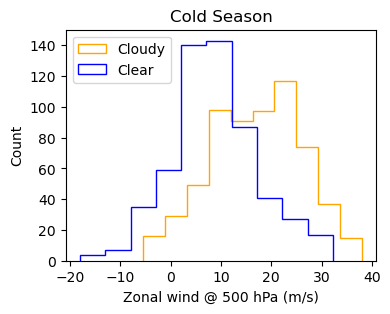

In [ ]:
#plt.scatter(warm_ssn z_erw.sel(time=warm_ssn.index).z, s=2)
warm_ssn_cld = warm_ssn[warm_ssn.cloud_base_best_estimate > .7]
warm_ssn_nocld = warm_ssn[warm_ssn.cloud_base_best_estimate < .1]


cold_ssn_cld = cold_ssn[cold_ssn.cloud_base_best_estimate > .7]
cold_ssn_nocld = cold_ssn[cold_ssn.cloud_base_best_estimate < .1]

fig,ax=plt.subplots(figsize=(4,3))

# z_erw.sel(time=warm_ssn_cld.index).u.plot.hist(histtype='step', bins=10, density=False, color='green',ax=ax, label="Cloudy")
# z_erw.sel(time=warm_ssn_nocld.index).u.plot.hist(histtype='step', bins=10, density=False, color='red', ax=ax, label="Clear")
# ax.set_title("Warm Season")


z_erw.sel(time=cold_ssn_cld.index).u.plot.hist(histtype='step', bins=10, density=False, color='orange', ax=ax, label="Cloudy")
z_erw.sel(time=cold_ssn_nocld.index).u.plot.hist(histtype='step', bins=10, density=False, color='blue', ax=ax, label="Clear")
ax.set_title("Cold Season")

ax.set_xlabel("Zonal wind @ 500 hPa (m/s)")
ax.set_ylabel("Count")
ax.legend(loc='upper left')


In [ ]:
erw_era5 = z_erw.to_pandas()

In [ ]:
erw_era5['u_norm'] = erw_era5.u / np.sqrt(erw_era5.u**2 + erw_era5.v**2)
erw_era5['v_norm'] = erw_era5.v / np.sqrt(erw_era5.u**2 + erw_era5.v**2)

In [ ]:
erw_era5['theta'] = np.arctan2(erw_era5.v_norm, erw_era5.u_norm)

In [ ]:
# # Create a polar plot
# fig, axx = plt.subplots(2, 2, figsize=(6,5), subplot_kw={'projection': 'polar'})

# #circular_hist(ax, df['theta_cold_ssn_cld'])
# circular_hist(axx[0,0], erw_era5['theta'].loc[cold_ssn_cld.index],  bins=48, label='no cloud')
# circular_hist(axx[1,0], erw_era5['theta'].loc[cold_ssn_nocld.index],  bins=48, label='no cloud')


# for ax in axx.flatten():
#     ax.set_theta_zero_location('N')
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.set_frame_on(False)


# axx[0,0].legend(loc='lower right')
# # # Show the plot
# # plt.show()
# plt.subplots_adjust(wspace=-.35)

# axx[0,0].set_title("Cold Season")
# axx[1,0].set_title("Warm Season")

In [ ]:
# udata=z_erw.sel(time=cold_ssn_cld.index).u.values.T
# vdata=z_erw.sel(time=cold_ssn_cld.index).v.values.T
# df=pd.DataFrame({"u":udata, "v":vdata})
# df['theta_cold_ssn_cld'] = np.arctan2(df.u, df.v)
# #counts_cld, bins_cld = np.histogram(df.theta_cld)

# udata=z_erw.sel(time=cold_ssn_nocld.index).u.values.T
# vdata=z_erw.sel(time=cold_ssn_nocld.index).v.values.T
# dfx=pd.DataFrame({"u":udata, "v":vdata})
# df['theta_cold_ssn_nocld'] = np.arctan2(dfx.u, dfx.v)
# #counts_nocld, bins_nocld = np.histogram(df.theta_nocld)



In [ ]:
# warm_ssn_cld = warm_ssn[warm_ssn.cloud_base_best_estimate > .7]
# warm_ssn_nocld = warm_ssn[warm_ssn.cloud_base_best_estimate < .1]


# ### do the warm season
# udata=z_erw.sel(time=warm_ssn_cld.index).u.values.T
# vdata=z_erw.sel(time=warm_ssn_cld.index).v.values.T
# dfx=pd.DataFrame({"u":udata, "v":vdata})

# df['theta_warm_ssn_cld'] = np.arctan2(dfx.u, dfx.v)
# #warm_counts_cld, warm_bins_cld = np.histogram(df.theta_cld)

# udata=z_erw.sel(time=warm_ssn_nocld.index).u.values.T
# vdata=z_erw.sel(time=warm_ssn_nocld.index).v.values.T
# dfx=pd.DataFrame({"u":udata, "v":vdata})
# df['theta_warm_ssn_nocld'] = np.arctan2(dfx.u, dfx.v)
# #warm_counts_nocld, warm_bins_nocld = np.histogram(df.theta_nocld)



In [ ]:
def circular_hist(x, bins=16, density=False):
    """
    Produce a circular histogram of angles on ax.

    Parameters
    ----------
    ax : matplotlib.axes._subplots.PolarAxesSubplot
        axis instance created with subplot_kw=dict(projection='polar').

    x : array
        Angles to plot, expected in units of radians.

    bins : int, optional
        Defines the number of equal-width bins in the range. The default is 16.

    density : bool, optional
        If True plot frequency proportional to area. If False plot frequency
        proportional to radius. The default is True.

    offset : float, optional
        Sets the offset for the location of the 0 direction in units of
        radians. The default is 0.

    gaps : bool, optional
        Whether to allow gaps between bins. When gaps = False the bins are
        forced to partition the entire [-pi, pi] range. The default is True.

    Returns
    -------
    n : array or list of arrays
        The number of values in each bin.

    bins : array
        The edges of the bins.

    patches : `.BarContainer` or list of a single `.Polygon`
        Container of individual artists used to create the histogram
        or list of such containers if there are multiple input datasets.
    """
    # Force bins to partition entire circle
    bins = np.linspace(-np.pi, np.pi, num=bins+1)

    # Bin data and record counts
    n, bins = np.histogram(x, bins=bins)

    # Compute width of each bin
    widths = np.diff(bins)

    # By default plot frequency proportional to area
    if density:
        # Area to assign each bin
        area = n / x.size
        # Calculate corresponding bin radius
        radius = (area/np.pi) ** .5

    # Otherwise plot frequency proportional to radius
    else:
        radius = n

    # Plot data on ax
#    patches = ax.bar(bins[:-1], radius, zorder=1, align='edge', width=widths,
#                     edgecolor='None', fill=True, facecolor=color, linewidth=0, alpha=.5, label=label)

    # Set the direction of the zero angle
#    ax.set_theta_offset(offset)

    # Remove ylabels for area plots (they are mostly obstructive)

    return n, bins, radius #patches

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Generate some data

# # Create a polar plot
# fig, axx = plt.subplots(1,2, figsize=(6,5), subplot_kw={'projection': 'polar'})

# #circular_hist(ax, df['theta_cold_ssn_cld'])
# circular_hist(axx[0], df['theta_cold_ssn_nocld'].dropna(), color='red', bins=48, label='no cloud')
# circular_hist(axx[0], df['theta_cold_ssn_cld'].dropna(), bins=24, label='cloud')

# circular_hist(axx[1], df['theta_warm_ssn_nocld'].dropna(), color='red', bins=48, label='no cloud')
# circular_hist(axx[1], df['theta_warm_ssn_cld'].dropna(), bins=24, label='cloud')

# for ax in axx.flatten():
#     ax.set_theta_zero_location('N')
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.set_frame_on(False)


# axx[0].legend(loc='lower right')
# # # Show the plot
# # plt.show()
# plt.subplots_adjust(wspace=-.35)

# axx[0].set_title("Cold Season")
# axx[1].set_title("Warm Season")

In [ ]:
# ## make wind magnitudes
# cold_ssn_cld_wmag = np.sqrt(z_erw.sel(time=cold_ssn_cld.index).u ** 2 + z_erw.sel(time=cold_ssn_cld.index).v **2)
# cold_ssn_nocld_wmag = np.sqrt(z_erw.sel(time=cold_ssn_nocld.index).u ** 2 + z_erw.sel(time=cold_ssn_nocld.index).v **2)

# warm_ssn_cld_wmag = np.sqrt(z_erw.sel(time=warm_ssn_cld.index).u ** 2 + z_erw.sel(time=warm_ssn_cld.index).v **2)
# warm_ssn_nocld_wmag = np.sqrt(z_erw.sel(time=warm_ssn_nocld.index).u ** 2 + z_erw.sel(time=warm_ssn_nocld.index).v **2)

In [ ]:
erw_era5['speed'] = np.sqrt(erw_era5.u**2 + erw_era5.v**2)

In [ ]:
def met_to_trig_convention(u,v):
    # we must flip the data about the y axis and then add 90 degrees 
    phi = np.arctan2(-1*v, u*-1)# - np.pi/2
    return phi

erw_era5['theta_met_convention'] = met_to_trig_convention(erw_era5.u, erw_era5.v)


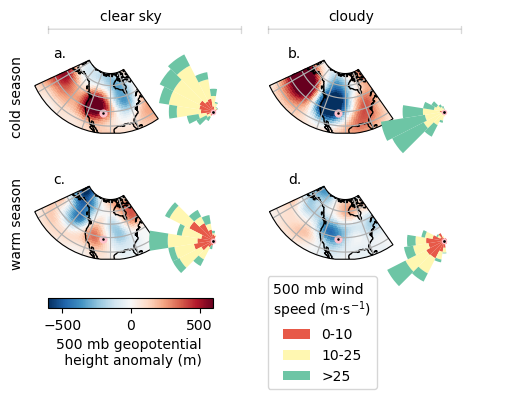

In [ ]:
nrows=2
ncols=4
fig, axs = plt.subplots(nrows=nrows,
                        ncols=ncols,
                        subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-100)},
                        figsize=(5.5,3), gridspec_kw={'width_ratios': [1, .6, 1, .4]})


for axzs in [axs[0,1], axs[1,1], axs[0,3], axs[1,3]]:
    axzs.set_visible(False)

                    

cb = make_figure(axs[0,0], anom_nocloud_cold, era_coarsen_interp.sel(time=cold_ssn_nocld.index).mean(dim='time'), vmin=-600, vmax=600)
make_figure(axs[0,2],      anom_hicloud_cold, era_coarsen_interp.sel(time=cold_ssn_cld.index).mean(dim='time'), vmin=-600, vmax=600)


cb = make_figure(axs[1,0], anom_nocloud_warm, era_coarsen_interp.sel(time=warm_ssn_nocld.index).mean(dim='time'), vmin=-600, vmax=600)
make_figure(axs[1,2],      anom_hicloud_warm, era_coarsen_interp.sel(time=warm_ssn_cld.index).mean(dim='time'), vmin=-600, vmax=600)


#cb1 = make_figure(axs[1], hgt_anom_warm, warm_season_cloud_pattern)

axs[0,0].set_title("")
axs[0,2].set_title("")
axs[1,0].set_title("")
axs[1,2].set_title("")

axs[0,0].text(-.2, .5, "cold season", transform=axs[0,0].transAxes, rotation=90, va='center')
axs[1,0].text(-.2, .5, "warm season", transform=axs[1,0].transAxes, rotation=90, va='center')

# label the direction
axs[0,0].text(.15, 1.1, "a.", transform=axs[0,0].transAxes, rotation=0, va='center')
axs[0,2].text(.15, 1.1, "b.", transform=axs[0,2].transAxes, rotation=0, va='center')
axs[1,0].text(.15, 1.1, "c.", transform=axs[1,0].transAxes, rotation=0, va='center')
axs[1,2].text(.15, 1.1, "d.", transform=axs[1,2].transAxes, rotation=0, va='center')


#cax =  fig.add_axes([.35, 0, 0.3, 0.035])
cax =  fig.add_axes([.15, 0, 0.3, 0.035])
cbar = fig.colorbar(cb, cax=cax, orientation='horizontal')
cbar.set_label("500 mb geopotential \n height anomaly (m)")

################

#fig, ax = plt.subplots(2,2, subplot_kw={'projection': 'polar'})

# # top row 
axa1 = fig.add_axes([.2,  .43,  0.5, 0.45], polar=True, frameon=False)
axa2 = fig.add_axes([.62, .43,  0.5, 0.45], polar=True, frameon=False)

# bottom row 
axa3 = fig.add_axes([.2,  .0,  0.5,  0.45], polar=True, frameon=False)
axa4 = fig.add_axes([.62, .0,  0.5,  0.45], polar=True, frameon=False)


# top row 
# axa1 = fig.add_axes([.2,  .53,  0.4, 0.4], polar=True, frameon=False)
# axa2 = fig.add_axes([.72, .53,  0.4, 0.4], polar=True, frameon=False)

# # bottom row 
# axa3 = fig.add_axes([.2,  .2,  0.4,  0.4], polar=True, frameon=False)
# axa4 = fig.add_axes([.72, .2,  0.4,  0.4], polar=True, frameon=False)




spec_cmap = plt.cm.get_cmap('Spectral', 20)
##### no clouds and warm season 
# low_wind = (erw_era5['theta_met_convention'].loc[cold_ssn_cld.index].where(erw_era5['speed'] < 15).dropna())
# mid_wind = (erw_era5['theta_met_convention'].loc[cold_ssn_cld.index].where(erw_era5['speed'] > 15).dropna())

def make_a_plot(data, ax):
    low_wind = data.where(data['speed'] < 10).theta_met_convention.dropna()
    mid_wind = data.where((data['speed'] > 10) & (data['speed'] < 20)).theta_met_convention.dropna()
    hih_wind = data.where(data['speed'] > 20).theta_met_convention.dropna()
    
    # low winds
    n, bins, radius = circular_hist(low_wind, bins=20)
    widths = [np.diff(bins)[0]]*len(bins[:-1])
    bin_centers = bins[:-1] + np.diff(bins)[0]/2
    bars1 = ax.bar(bin_centers, radius, color=spec_cmap(.15), alpha=1, align='edge', fill=True, width=widths, label='0-10')

    # medium winds 
    n2, bin2, radius2 = circular_hist(mid_wind, bins=20)
    widths = [np.diff(bin2)[0]]*len(bin2[:-1])
    bin_centers = bin2[:-1] + np.diff(bin2)[0]/2
    bars2 = ax.bar(bin_centers, radius2, bottom=radius, color=spec_cmap(.45),  alpha=1, align='edge',fill=True, width=widths, label='10-25')
    
    # high winds 
    n3, bin3, radius3 = circular_hist(hih_wind, bins=20)
    widths = [np.diff(bin3)[0]]*len(bins[:-1])
    bin_centers = bin3[:-1] + np.diff(bin3)[0]/2
    bars3 = ax.bar(bin_centers, radius3, bottom=radius+radius2, color=spec_cmap(.75), alpha=1, align='edge', fill=True,width=widths, label='>25')
    
    # get the handles 
    handles = [bars1, bars2, bars3]
    labels = [bars1[0].get_label(), bars2[0].get_label(), bars3[0].get_label()]
    return handles, labels 

#####
make_a_plot(erw_era5.loc[cold_ssn_nocld.index], axa1)
make_a_plot(erw_era5.loc[cold_ssn_cld.index],  axa2)

make_a_plot(erw_era5.loc[warm_ssn_nocld.index], axa3)
handles, labels = make_a_plot(erw_era5.loc[warm_ssn_cld.index],   axa4)


##### 
# ax[0,0].set_title("Warm Season, No Clouds")
# ax[0,1].set_title("Warm Season, Clouds")
# ax[1,0].set_title("Cold Season, No Clouds")
# ax[1,1].set_title("Cold Season, Clouds")


#ax.set_theta_zero_location('N')
#n, bins, radius = circular_hist((erw_era5['theta_met_convention'].loc[cold_ssn_nocld.index].dropna()), color='red', bins=48, label='clear')
#widths = np.diff(bins)
#ax.bar(bins[:-1], radius, color='red', label='clear', alpha=.5, align='edge', width=widths)

#ax.set_yticks([])
#ax.set_xticks([])
#ax.set_xticks([np.pi/2, 3/4*np.pi, 5/4*np.pi, np.pi, 3*np.pi/2])  
#ax.set_xticklabels(["N", "NE", "W", "SW", "S"])
i=0
for axx in [axa1, axa2, axa3, axa4]:
    axx.set_yticks([])
    axx.set_xticks([3/4*np.pi, 5/4*np.pi, np.pi])
    axx.set_frame_on(False)
    axx.set_axis_off()    
    if i in [0,2]:
        axx.set_xticklabels([])#"NW", "W", "SW"])
    else:
        axx.set_xticklabels([])
    i+=1
    axx.scatter(0,0, s=9, facecolor='black', edgecolor='pink')

#fig.subplots_adjust(wspace=.9)

leg = axa4.legend(handles, ['0-10','10-25', '>25'], ncols=1, loc='lower right', bbox_to_anchor=(.05, -.65))
leg.set_title("500 mb wind\n"+ r"speed (m$\cdot$s$^{-1}$)")



##### draw some connection line things over the two...


fig.text((.15 + .45)*.5, .96, "clear sky", transform=fig.transFigure, rotation=0, ha='center')
fig.text((.55 + .85)*.5, .96, "cloudy",    transform=fig.transFigure, rotation=0, ha='center')

#fig.transFigure, figure=fig)



# this is the top left one under 'clear sky'
con = ConnectionPatch(
    # in axes coordinates
    xyA =(0.15, .93), coordsA = fig.transFigure,  
    # x in axes coordinates, y in data coordinates
    xyB =(0.5, .93), coordsB = fig.transFigure, 
    mutation_scale=2.5,
    alpha=.15,
    arrowstyle ="|-|")
 
fig.add_artist(con)

# add antother one ..
con = ConnectionPatch(
    # in axes coordinates
    xyA =(0.55, .93), coordsA = fig.transFigure,  
    # x in axes coordinates, y in data coordinates
    xyB =(0.90, .93), coordsB = fig.transFigure, 
    mutation_scale=2.5,
    alpha=.15,
    arrowstyle ="|-|")
 
fig.add_artist(con)

plt.savefig("/global/homes/r/rudisill/gshare2/will_data/cre_project_images/FigureX_era_interim_wind_and_pressure", dpi=300,  bbox_inches="tight")

In [ ]:
params

<xarray.Dataset>
Dimensions:            (latitude: 41, longitude: 101, doy: 365,
                        trend_params: 2, cluster: 5, pc: 12)
Coordinates:
  * latitude           (latitude) float32 80.0 78.5 77.0 75.5 ... 23.0 21.5 20.0
  * longitude          (longitude) float32 -180.0 -178.5 -177.0 ... -31.5 -30.0
Dimensions without coordinates: doy, trend_params, cluster, pc
Data variables:
    z_climo            (doy, latitude, longitude) float64 ...
    norm_factor        (doy) float64 ...
    trend              (trend_params) float64 ...
    cluster_centroids  (cluster, pc) float64 ...

In [ ]:
era_coarsen_interp.sel(time=test_date)

<xarray.Dataset>
Dimensions:    (latitude: 41, longitude: 101)
Coordinates:
    expver     int32 1
    time       datetime64[ns] 2023-01-03
  * latitude   (latitude) float32 80.0 78.5 77.0 75.5 ... 24.5 23.0 21.5 20.0
  * longitude  (longitude) float32 -180.0 -178.5 -177.0 ... -33.0 -31.5 -30.0
Data variables:
    z          (latitude, longitude) float32 nan nan nan ... 5.726e+04 5.726e+04
    u          (latitude, longitude) float32 nan nan nan ... 3.749 3.969 4.197
    v          (latitude, longitude) float32 nan nan nan ... -2.761 -2.91 -2.067
Attributes:
    Conventions:  CF-1.6
    history:      2024-02-07 02:35:43 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

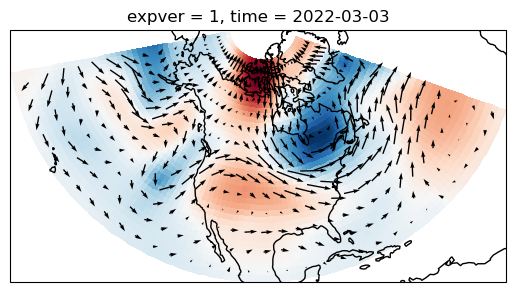

In [ ]:
test_date = pd.to_datetime('2022-03-03')
data = era_coarsen_interp.sel(time=test_date)# - 9.81*params.z_climo.loc[params.z_climo.doy.isin(test_date.dayofyear)].mean(dim="doy")
zanom = data.z - 9.81*params.z_climo.loc[params.z_climo.doy.isin(test_date.dayofyear)].mean(dim="doy")

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-100)})

cb = ax.pcolormesh(zanom.longitude, 
                    zanom.latitude, 
                    zanom,
                    cmap='RdBu_r', 
                    transform=ccrs.PlateCarree(), 
                    shading='auto')
ax.coastlines()                

wind_downsample = data[{'latitude': slice(None, None, 3), 
                        'longitude': slice(None, None, 3)}]

qplot = wind_downsample.plot.quiver('longitude', 
                                    'latitude', 
                                    'u', 
                                    'v',
                                    transform=ccrs.PlateCarree(), 
                                    scale=800, 
                                    ax=ax, 
                                    add_guide=False)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Define the colormap
cmap = plt.cm.get_cmap('Spectral')

# Define the value to get the color for
value = 0.5

# Normalize the value to the range [0, 1]
norm = colors.Normalize(vmin=0, vmax=1)
normalized_value = norm(value)

# Get the color value from the colormap
color = cmap(normalized_value)

# Print the color value
print(color)

(0.998077662437524, 0.9992310649750096, 0.7460207612456747, 1.0)


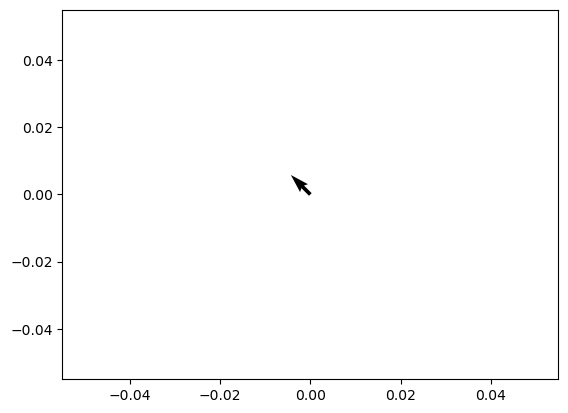

In [ ]:
fig,ax = plt.subplots(1)
ax.quiver(0, 0, -1, 1)


<BarContainer object of 1 artists>

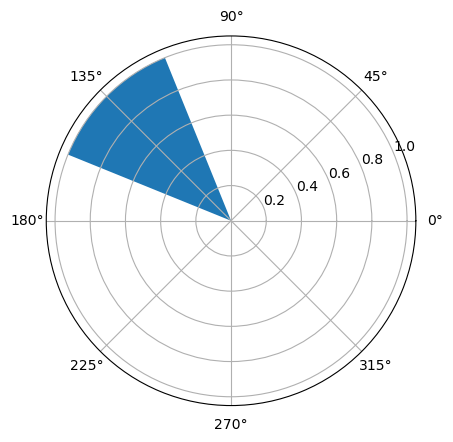

In [ ]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
#ax.bar(np.arctan2(1, -1), 1)

ax.bar(np.arctan2(-1*-1, -1), 1)
#ax.set_theta_zero_location('N')


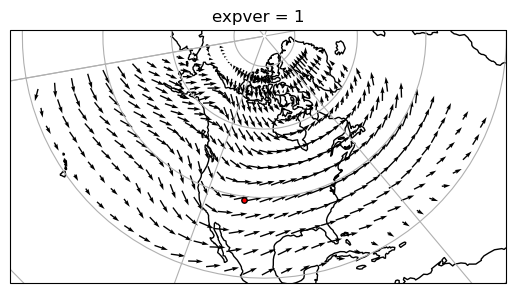

In [ ]:
test = era_coarsen_interp.sel(time=cold_ssn_cld.index)[{'latitude': slice(None, None, 3), 
                                                        'longitude': slice(None, None, 3)}]

#test.isel(time=10).u.plot()
u = test.u / np.sqrt(test.u**2 + test.v**2)
v = test.v / np.sqrt(test.u**2 + test.v**2)


test['un'] = u
test['vn'] = v



fig, ax = plt.subplots(subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-100)})
#time = 5
# ax.pcolormesh(test.mean(dim='time').longitude, 
#               test.mean(dim='time').latitude, 
#               test.mean(dim='time').z, 
#             cmap='RdBu_r', 
#             transform=ccrs.PlateCarree(), 
#             shading='auto')#vmax=vmax, vmin=vmin)

#test.median(dim='time')
test.median(dim='time').plot.quiver('longitude', 
                                    'latitude', 
                                    'un', 
                                    'vn',
                                    transform=ccrs.PlateCarree(), 
#                                    scale=300, 
                                    ax=ax, 
                                    pivot="middle",
                                    add_guide=False)


ax.gridlines()
ax.coastlines()


erw_latitude  = 38.956381  # ERW
erw_longitude = -106.984322  # ERW

ax.scatter(erw_longitude, erw_latitude, transform=ccrs.PlateCarree(), s=15, c='r', edgecolor='k', linewidth=1)



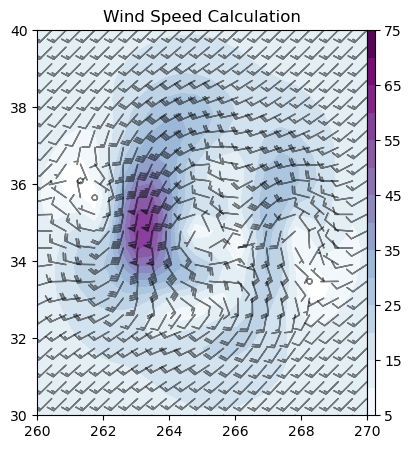

In [ ]:
import matplotlib.pyplot as plt

import metpy.calc as mpcalc
from metpy.cbook import example_data

# load example data
ds = example_data()

# Calculate the total deformation of the flow
wind_speed = mpcalc.wind_speed(ds.uwind, ds.vwind)

# start figure and set axis
fig, ax = plt.subplots(figsize=(5, 5))

# plot wind speed
cf = ax.contourf(ds.lon, ds.lat, wind_speed, range(5, 80, 5), cmap=plt.cm.BuPu)
plt.colorbar(cf, pad=0, aspect=50)
ax.barbs(ds.lon.values, ds.lat.values, ds.uwind, ds.vwind, color='black', length=5, alpha=0.5)
ax.set(xlim=(260, 270), ylim=(30, 40))
ax.set_title('Wind Speed Calculation')

plt.show()

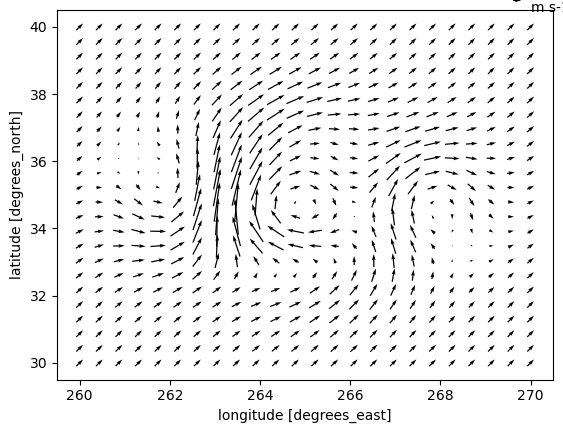

In [ ]:
ds.plot.quiver('lon', 'lat', 'uwind', 'vwind')
#circular_hist(axclrhist, erw_era5['theta'].loc[cold_ssn_cld.index].dropna(), color='blue', bins=48, label="cloudy")

In [ ]:
# the_time = pd.to_datetime('2023-02-03')

# nrows=2
# ncols=2
# fig, axs = plt.subplots(nrows=nrows,
#                         ncols=ncols,
#                         subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-100)},
#                         figsize=(5.5,3))


                    

# cb = make_figure(axs[0,0], anom_nocloud_cold, era_coarsen_interp.sel(time=cold_ssn_nocld.index).mean(dim='time'), vmin=-600, vmax=600)
# make_figure(axs[0,1], anom_hicloud_cold, era_coarsen_interp.sel(time=cold_ssn_cld.index).mean(dim='time'), vmin=-600, vmax=600)


# cb = make_figure(axs[1,0], anom_nocloud_warm, era_coarsen_interp.sel(time=warm_ssn_nocld.index).mean(dim='time'), vmin=-600, vmax=600)
# make_figure(axs[1,1], anom_hicloud_warm, era_coarsen_interp.sel(time=warm_ssn_cld.index).mean(dim='time'), vmin=-600, vmax=600)


# #cb1 = make_figure(axs[1], hgt_anom_warm, warm_season_cloud_pattern)

# axs[0,0].set_title("")
# axs[0,1].set_title("")
# axs[1,0].set_title("")
# axs[1,1].set_title("")

# axs[0,0].text(-.1, .5, "clear", transform=axs[0,0].transAxes, rotation=90, va='center')
# axs[1,0].text(-.1, .5, "clear", transform=axs[1,0].transAxes, rotation=90, va='center')

# axs[0,1].text(-.1, .5, "cloudy", transform=axs[0,1].transAxes, rotation=90, va='center')
# axs[1,1].text(-.1, .5, "cloudy", transform=axs[1,1].transAxes, rotation=90, va='center')

# cax =  fig.add_axes([.35, 0, 0.3, 0.035])
# cbar = fig.colorbar(cb, cax=cax, orientation='horizontal')
# cbar.set_label("500 mb geopotential height anomaly (m)")

# ### make some histogram things down here...

# #axclrhist = fig.add_axes([.05, -.7, 0.5, 0.5], polar=True, frameon=False)
# axclrhist = fig.add_axes([.85, .48, 0.5, 0.45], polar=True, frameon=False)

# circular_hist(axclrhist, 
#               -1 * (erw_era5['theta'].loc[cold_ssn_nocld.index].dropna() + np.pi),
#                     erw_era5['speed'].loc[cold_ssn_nocld.index].dropna(), 
#                     color='red', bins=48, label='clear')

# circular_hist(axclrhist, -1 * (erw_era5['theta'].loc[cold_ssn_cld.index].dropna()   + np.pi), 
#                                erw_era5['speed'].loc[cold_ssn_cld.index].dropna(), 
#             color='blue', bins=48, label="cloudy")


# axclrhist.set_theta_zero_location('N')


# #axcldhist = fig.add_axes([.25, -.7, 0.5, 0.5], polar=True, frameon=False)
# axcldhist = fig.add_axes([.85, .0, 0.5, 0.45], polar=True, frameon=False)
 

# #circular_hist(axcldhist, erw_era5['theta'].dropna(), color='gray', bins=48, label="all")
# circular_hist(axcldhist, 
#               -1 * (erw_era5['theta'].loc[warm_ssn_nocld.index].dropna() + np.pi), 
#                     erw_era5['speed'].loc[warm_ssn_nocld.index].dropna(), 
#               color='red', bins=48, label='clear')


# circular_hist(axcldhist, 
#               -1 * (erw_era5['theta'].loc[warm_ssn_cld.index].dropna() + np.pi), 
#                     erw_era5['speed'].loc[warm_ssn_cld.index].dropna(), 
#             color='blue', bins=48, label="cloudy")

            
# axcldhist.set_theta_zero_location('N')
# #axclrhist.legend(loc='upper left')
# axcldhist.set_xlabel("wind direction")
# axcldhist.xaxis.set_label_coords(.25, -.12)


# for axz in [axclrhist, axcldhist]:
#     axz.set_xticks([np.pi/4, np.pi/2, 3*np.pi/4])
#     axz.set_xticklabels(["NW", "W", "SW"])
# axclrhist.legend(loc='lower right', bbox_to_anchor=(1.125, -.25))

# axs[0,0].text(0, 1.05, "cold season", transform=axs[0,0].transAxes)
# axs[1,0].text(0, 1.05, "warm season", transform=axs[1,0].transAxes)




# #plt.savefig("/global/homes/r/rudisill/gshare2/will_data/cre_project_images/FigureX_era_interim", dpi=300,  bbox_inches="tight")
